In [55]:
import json 

input_path_raw = '../../data/thinkrl/2025-09-22T12:25:10.256274_telecom-workflow_llm_agent_gpt-5-nano_user_simulator_gpt-5.json'

with open(input_path_raw, 'r') as f:
    raw = json.load(f)

input_path_with_judge = '../../data/thinkrl/2025-09-22T12:25:10.256274_telecom-workflow_llm_agent_gpt-5-nano_user_simulator_gpt-5_rollouts_only_with_judgments.json'

with open(input_path_with_judge, 'r') as f:
    raw_with_judge = json.load(f)

In [56]:
rollouts = raw_with_judge.get('simulations')

tasks = raw.get('tasks')
simulations_with_rewards = raw.get('simulations')

In [51]:
def find_dict_by_key_value(dict_array, key, value):
    """
    Loop through an array of dictionaries and return the first element
    where the specified key has the specified value.

    Args:
        dict_array: List of dictionaries to search through
        key: The key to check in each dictionary
        value: The value to match for the specified key

    Returns:
        The first dictionary element that matches, or None if not found
    """
    for element in dict_array:
        if element.get(key) == value:
            return element
    return None

def find_reward_for_task_id(id):
    out= find_dict_by_key_value(simulations_with_rewards, 'id', id)
    if out is None:
        raise ValueError(f"Could not find simulation with id {id}")
    return out['reward_info']

def find_task_info(task_id):
    out= find_dict_by_key_value(tasks, 'id', task_id)
    if out is None:
        raise ValueError(f"Could not find task with id {task_id}")
    return out

In [52]:
rollouts[0]['judgment']

{'verdict': 'PASS',
 'debug_info': 'Evidence of customer confirmation of fix:\n- jq: .[] | select(.turn_idx==21) | .content\n  - "Mobile Data is now ON. I ran a speed test and got 275 Mbps, which is marked Excellent... my issue is resolved now."\n\nEvidence of customer identification attempts per policy:\n- jq: .[] | select(.turn_idx==2)         # Tool call (get_customer_by_phone) with empty input (error)\n- jq: .[] | select(.turn_idx==4) | .content\n  - Agent asks for Customer ID or full name + DOB; offers formatted phone number retry.\n- jq: .[] | select(.turn_idx==6)         # Tool call (get_customer_by_phone "+1 555-123-2002")\n- jq: .[] | select(.turn_idx==7)         # Tool error: not found\n- jq: .[] | select(.turn_idx==8) | .content\n  - Agent requests Customer ID or full name + DOB; proceeds with device-side step (reboot) while awaiting verification.\n\nGrounding in user-reported status and policy-guided steps:\n- User reports after reboot, Airplane Mode icon is visible:\n  - j

In [57]:

# tasks[0]

for rollout in rollouts:
    # print(rollout)
    judgement = rollout.get('judgment')
    if judgement is None:
        # print("No judgement")
        # print(rollout)
        continue
    print(judgement)
    print(rollout['task_id'])
    print(rollout['id'])
    reward = find_reward_for_task_id(rollout['id'])
    print(reward)
    info = find_task_info(rollout['task_id'])
    print(info)
    messages = rollout['messages']
    print(messages)
    judgement = rollout.get('judgement')
    print(judgement)
    print(rollout.keys())
    # break
    

{'verdict': 'FAIL', 'debug_info': '- Evidence of premature escalation:\n  - Tool error on phone lookup: jq \'.[] | select(.turn_idx==7)\'\n    - Content: "Error: Customer with phone number +1 555-123-2002 not found"\n  - Immediate transfer tool call right after single failed lookup: jq \'.[] | select(.turn_idx==8)\'\n    - Name: transfer_to_human_agents, Summary indicates identity verification required.\n  - Transfer notice to user: jq \'.[] | select(.turn_idx==10)\'\n    - "YOU ARE BEING TRANSFERRED TO A HUMAN AGENT. PLEASE HOLD ON."\n- Relevant policy requirements not followed:\n  - Main policy: "You should try your best to resolve the issue for the user before transferring the user to a human agent." The agent could still:\n    - Request DOB to perform name+DOB lookup (policy: "For name lookup, date of birth is required"). The user had provided full name at turn_idx 5, but the agent did not ask for DOB after the phone lookup failed.\n    - Alternatively request Customer ID or re-con

In [61]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extract reward and verdict data
data = []
for rollout in rollouts:
    judgment = rollout.get('judgment')
    if judgment is None:
        continue
    
    # Get verdict (1 for PASS, 0 for FAIL)
    verdict = 1 if judgment['verdict'] == 'PASS' else 0
    
    # Get reward from reward_info
    try:
        reward_info = find_reward_for_task_id(rollout['id'])
        reward = reward_info['reward']

        match_info = ''
        if reward > 0 and verdict == 1:
            match_info = 'True Positive'
        elif reward == 0 and verdict == 0:
            match_info = 'True Negative'
        elif reward > 0 and verdict == 0:
            match_info = 'False Negative'
        elif reward == 0 and verdict == 1:
            match_info = 'False Positive'
        else:
            match_info = 'Unknown'
        
        data.append({
            'id': rollout['id'],
            'task_id': rollout['task_id'],
            'verdict': verdict,
            'verdict_label': judgment['verdict'],
            'reward': reward,
            'match': match_info,
            'messages': rollout['messages'],
            'judgment': judgment
        })
    except ValueError as e:
        print(f"Could not find reward for {rollout['id']}: {e}")
        continue

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"Total samples: {len(df)}")
print(f"PASS count: {sum(df['verdict'])}")
print(f"FAIL count: {len(df) - sum(df['verdict'])}")
print(f"Reward > 0 count: {sum(df['reward'] > 0)}")
print(f"Reward = 0 count: {sum(df['reward'] == 0)}")

df.head()

Total samples: 23
PASS count: 10
FAIL count: 13
Reward > 0 count: 14
Reward = 0 count: 9


,id,task_id,verdict,verdict_label,reward,match,messages,judgment
0,fe9636f5-8e16-42fb-9494-9c51a3dfb269,[mobile_data_issue]bad_network_preference|user...,0,FAIL,0.0,True Negative,"[{'role': 'assistant', 'content': 'Hi! How can...","{'verdict': 'FAIL', 'debug_info': '- Evidence ..."
1,786e9885-a5a5-4ad9-b5cb-79b99c4b29c6,[mobile_data_issue]data_saver_mode_on|user_abr...,0,FAIL,1.0,False Negative,"[{'role': 'assistant', 'content': 'Hi! How can...","{'verdict': 'FAIL', 'debug_info': 'Evidence: -..."
2,4d707ad7-271c-4dc3-83c4-5b992aa7cbd5,[mobile_data_issue]airplane_mode_on|user_abroa...,1,PASS,1.0,True Positive,"[{'role': 'assistant', 'content': 'Hi! How can...","{'verdict': 'PASS', 'debug_info': 'Evidence th..."
3,198ba482-11ee-4c5e-8a9a-717cb028a4b5,[mobile_data_issue]airplane_mode_on|bad_networ...,1,PASS,1.0,True Positive,"[{'role': 'assistant', 'content': 'Hi! How can...","{'verdict': 'PASS', 'debug_info': '- Customer ..."
4,e928cfb6-d39e-4140-ae45-ed18827aeb28,[mobile_data_issue]data_mode_off|data_usage_ex...,0,FAIL,1.0,False Negative,"[{'role': 'assistant', 'content': 'Hi! How can...","{'verdict': 'FAIL', 'debug_info': 'Key issues ..."


In [59]:
# Convert rewards to binary (1 for reward > 0, 0 for reward = 0)
df['reward_binary'] = (df['reward'] > 0).astype(int)

# Create confusion matrix
# True labels: verdict (1=PASS, 0=FAIL)
# Predicted labels: reward_binary (1=reward>0, 0=reward=0)
cm = confusion_matrix(df['verdict'], df['reward_binary'])

print("Confusion Matrix:")
print("Rows: Actual Verdict (0=FAIL, 1=PASS)")
print("Cols: Reward Binary (0=reward=0, 1=reward>0)")
print(cm)

# Create a more detailed breakdown
print("\nDetailed breakdown:")
print(pd.crosstab(df['verdict_label'], df['reward_binary'], 
                 rownames=['Actual Verdict'], colnames=['Reward Binary']))

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMetrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

# Show agreement/disagreement cases
print(f"\nAgreement analysis:")
print(f"Both PASS and reward>0: {tp}")
print(f"Both FAIL and reward=0: {tn}")
print(f"PASS but reward=0: {fn}")
print(f"FAIL but reward>0: {fp}")

Confusion Matrix:
Rows: Actual Verdict (0=FAIL, 1=PASS)
Cols: Reward Binary (0=reward=0, 1=reward>0)
[[7 6]
 [2 8]]

Detailed breakdown:
Reward Binary   0  1
Actual Verdict      
FAIL            7  6
PASS            2  8

Metrics:
Accuracy: 0.652
Precision: 0.571
Recall: 0.800
F1-score: 0.667

Agreement analysis:
Both PASS and reward>0: 8
Both FAIL and reward=0: 7
PASS but reward=0: 2
FAIL but reward>0: 6


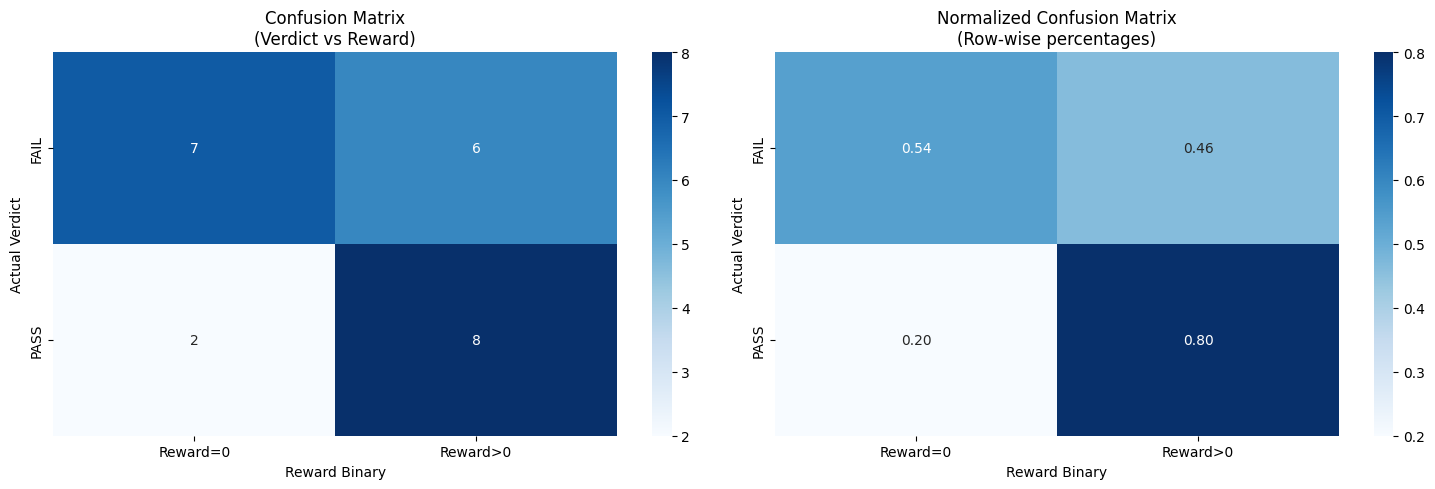

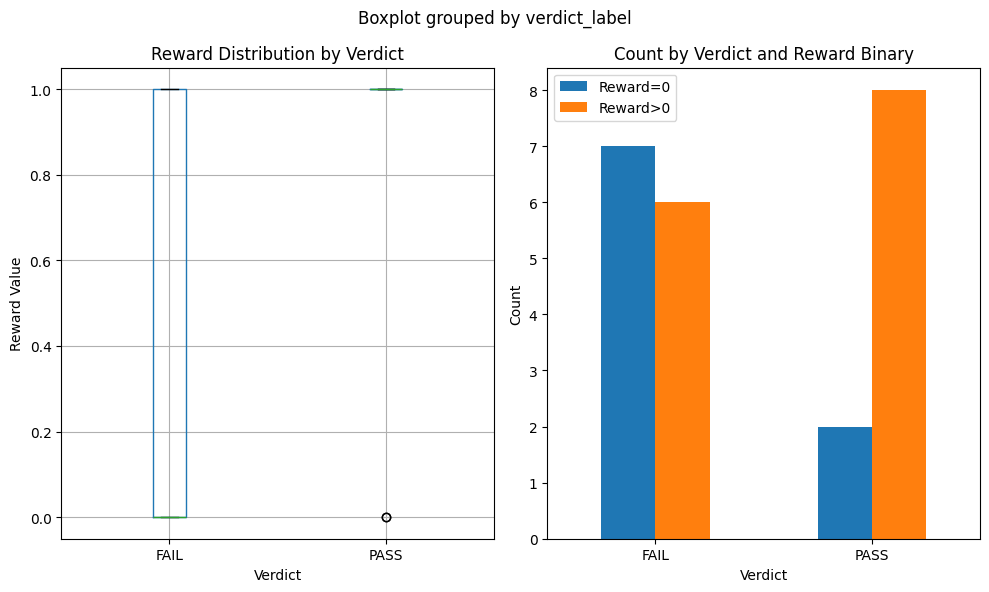

In [60]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Reward=0', 'Reward>0'],
            yticklabels=['FAIL', 'PASS'],
            ax=ax1)
ax1.set_title('Confusion Matrix\n(Verdict vs Reward)')
ax1.set_xlabel('Reward Binary')
ax1.set_ylabel('Actual Verdict')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Reward=0', 'Reward>0'],
            yticklabels=['FAIL', 'PASS'],
            ax=ax2)
ax2.set_title('Normalized Confusion Matrix\n(Row-wise percentages)')
ax2.set_xlabel('Reward Binary')
ax2.set_ylabel('Actual Verdict')

plt.tight_layout()
plt.show()

# Additional analysis: show actual reward values by verdict
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df.boxplot(column='reward', by='verdict_label', ax=plt.gca())
plt.title('Reward Distribution by Verdict')
plt.xlabel('Verdict')
plt.ylabel('Reward Value')

plt.subplot(1, 2, 2)
verdict_counts = df.groupby(['verdict_label', 'reward_binary']).size().unstack(fill_value=0)
verdict_counts.plot(kind='bar', ax=plt.gca())
plt.title('Count by Verdict and Reward Binary')
plt.xlabel('Verdict')
plt.ylabel('Count')
plt.legend(['Reward=0', 'Reward>0'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()